<a href="https://colab.research.google.com/github/malepatideenatha28/milestone_project/blob/main/milestone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [22]:
attendance = pd.read_csv("/content/Attendance_Dataset.csv")
print("Dataset Shape:", attendance.shape)
attendance.head()

Dataset Shape: (980, 44)


,Student_Name,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,Day_8,Day_9,...,Day_34,Day_35,Day_36,Day_37,Day_38,Day_39,Day_40,Total_Present,Attendance_%,Certification_Status
0,Anuswetha Rangala,1,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,37,92.5,Certified
1,Rakshitha-24F41A0581 ( Rakshitha Reddy ),1,1,1,0,0,0,1,1,1,...,1,1,1,0,1,1,1,30,75.0,Not Certified
2,Suragani Lali sai,1,0,1,1,1,0,1,1,0,...,1,1,1,1,1,1,0,33,82.5,Certified
3,Hemanth - DATA ANALYSIS USING PYTHON,1,1,1,0,1,0,1,1,1,...,1,1,1,1,1,1,0,31,77.5,Not Certified
4,MOHAMMED ARSHIYA,1,1,0,0,1,1,1,1,1,...,1,1,1,0,1,1,1,31,77.5,Not Certified


In [23]:
print("\nMissing Values:\n")
print(attendance.isnull().sum())

print("\nDuplicate Records:")
print(attendance.duplicated().sum())


Missing Values:

Student_Name            0
Day_1                   0
Day_2                   0
Day_3                   0
Day_4                   0
Day_5                   0
Day_6                   0
Day_7                   0
Day_8                   0
Day_9                   0
Day_10                  0
Day_11                  0
Day_12                  0
Day_13                  0
Day_14                  0
Day_15                  0
Day_16                  0
Day_17                  0
Day_18                  0
Day_19                  0
Day_20                  0
Day_21                  0
Day_22                  0
Day_23                  0
Day_24                  0
Day_25                  0
Day_26                  0
Day_27                  0
Day_28                  0
Day_29                  0
Day_30                  0
Day_31                  0
Day_32                  0
Day_33                  0
Day_34                  0
Day_35                  0
Day_36                  0
Day_37              

In [24]:
certified=(attendance["Certification_Status"]=="Certified").sum()
not_certified = (attendance["Certification_Status"]== "Not Certified").sum()
print("Certified Students:",certified)
print("Not Certified Students:",not_certified)

Certified Students: 646
Not Certified Students: 334


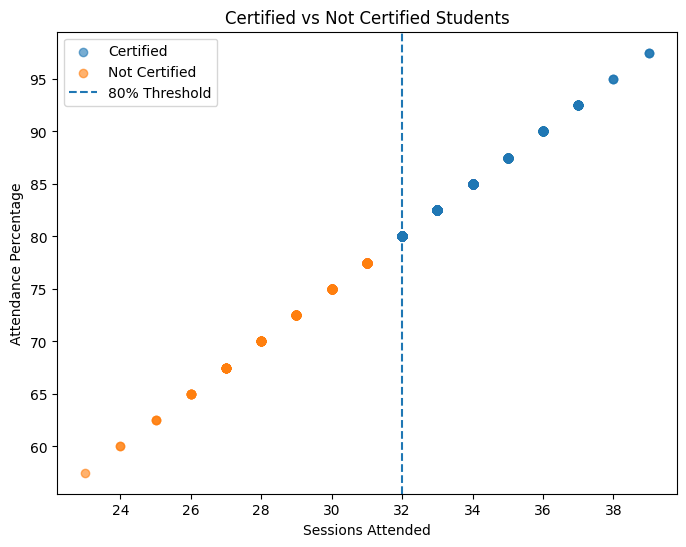

In [25]:
cert_students = attendance[attendance["Certification_Status"]=="Certified"]
not_cert_students = attendance[attendance["Certification_Status"]=="Not Certified"]

plt.figure(figsize=(8,6))

plt.scatter(
    cert_students["Total_Present"],
    cert_students["Attendance_%"],
    label="Certified",
    alpha=0.6
)

plt.scatter(
    not_cert_students["Total_Present"],
    not_cert_students["Attendance_%"],
    label="Not Certified",
    alpha=0.6
)

plt.axvline(
    x=32,
    linestyle="--",
    label="80% Threshold"
)

plt.xlabel("Sessions Attended")
plt.ylabel("Attendance Percentage")
plt.title("Certified vs Not Certified Students")

plt.legend()

plt.show()

In [26]:
X = attendance[["Total_Present", "Attendance_%"]]
y = attendance["Certification_Status"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test,dt_pred)
print("Decision Tree Accuracy:",round(dt_accuracy*100,2),"%")

Decision Tree Accuracy: 100.0 %


In [28]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:",round(rf_accuracy*100,2),"%")

Random Forest Accuracy: 100.0 %


In [29]:
print("====Attendance Certification System Using Machine Learning====")
print("Total Students:",len(attendance))
print("Total Sessions:",40)
print("Certified Students:",certified)
print("Not Certified Students:",not_certified)

====Attendance Certification System Using Machine Learning====
Total Students: 980
Total Sessions: 40
Certified Students: 646
Not Certified Students: 334
